In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [2]:
!pip install -q pandas numpy scikit-learn streamlit pyngrok
print("Libraries installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 69.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 81.7 MB/s eta 0:00:00
Libraries installed successfully!


In [3]:
# Load dataset
df = pd.read_csv('/content/Palo_Alto_Networks.csv')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1470, 31)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [4]:
print("--- BASIC DATA INSPECTION ---")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

--- BASIC DATA INSPECTION ---
Total Rows: 1470
Total Columns: 31


In [5]:
# Check for duplicate values
duplicate_count = df.duplicated().sum()
print(f"Number of Duplicate Rows: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed successfully.")
else:
    print("No duplicate rows found.")

Number of Duplicate Rows: 0
No duplicate rows found.


In [6]:
# Check for missing values
print("\n--- MISSING VALUES CHECK ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("Result: Zero missing values found in the dataset.")
else:
    # If missing values exist, handle them safely:
    # Numeric -> median, Categorical -> mode
    for col in df.select_dtypes(include=[np.number]).columns:
        df[col].fillna(df[col].median(), inplace=True)
    for col in df.select_dtypes(include=['object']).columns:
        df[col].fillna(df[col].mode()[0], inplace=True)
    print("Missing values imputed successfully.")


--- MISSING VALUES CHECK ---
Series([], dtype: int64)
Result: Zero missing values found in the dataset.


In [7]:
print("--- CATEGORICAL ENCODING ---")
categorical_cols = df.select_dtypes(include=['object']).columns
print("Categorical columns to encode:", list(categorical_cols))

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("Encoding complete. All columns are now numerical.")

--- CATEGORICAL ENCODING ---
Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Encoding complete. All columns are now numerical.


In [8]:
print("--- FEATURE ENGINEERING ---")

# 1. Income-to-experience ratio
df['IncomeToExperience'] = df['MonthlyIncome'] / (df['TotalWorkingYears'] + 1)

# 2. Promotion delay indicators
df['PromotionDelay'] = df['YearsAtCompany'] - df['YearsSinceLastPromotion']

# 3. Engagement composite score
df['EngagementScore'] = (
    df['EnvironmentSatisfaction'] +
    df['JobSatisfaction'] +
    df['RelationshipSatisfaction'] +
    df['WorkLifeBalance']
)

# 4. Workload stress flag (OverTime)
df['WorkloadStress'] = df['OverTime']

print("New engineered features added successfully!")
df[['IncomeToExperience', 'PromotionDelay', 'EngagementScore', 'WorkloadStress']].head()

--- FEATURE ENGINEERING ---
New engineered features added successfully!


,IncomeToExperience,PromotionDelay,EngagementScore,WorkloadStress
0,665.888889,6,8,1
1,466.363636,9,12,0
2,261.250000,0,12,1
3,323.222222,5,13,1
4,495.428571,0,10,0


In [9]:
print("--- TRAIN-TEST SPLIT ---")

X = df.drop(columns=['Attrition'])
y = df['Attrition']

# Split data: 80% train, 20% test with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"Attrition proportion in train set: {y_train.mean():.2%}")

--- TRAIN-TEST SPLIT ---
Training set shape: (1176, 34)
Testing set shape: (294, 34)
Attrition proportion in train set: 16.16%


In [10]:
print("--- MODEL TRAINING & EVALUATION ---")

# Train Random Forest Classifier with class weights to account for class imbalance
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

# Predictions & Probabilities
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Metrics
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

--- MODEL TRAINING & EVALUATION ---
Confusion Matrix:
 [[241   6]
 [ 43   4]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.40      0.09      0.14        47

    accuracy                           0.83       294
   macro avg       0.62      0.53      0.52       294
weighted avg       0.78      0.83      0.79       294

ROC-AUC Score: 0.7700


In [11]:
print("--- RISK SCORING FRAMEWORK ---")

risk_df = pd.DataFrame({
    'Employee_Index': X_test.index,
    'Attrition_Probability': y_prob
})

# Assign Risk Categories based on project threshold rules:
# Low Risk (<30%), Medium Risk (30–60%), High Risk (>60%)[cite: 8]
def assign_risk_category(prob):
    if prob < 0.30:
        return 'Low Risk (<30%)'
    elif prob <= 0.60:
        return 'Medium Risk (30–60%)'
    else:
        return 'High Risk (>60%)'

risk_df['Risk_Category'] = risk_df['Attrition_Probability'].apply(assign_risk_category)

print("Risk Category Distribution in Test Set:")
print(risk_df['Risk_Category'].value_counts())

print("\nSample Risk Scoring Output:")
risk_df.head(10)

--- RISK SCORING FRAMEWORK ---
Risk Category Distribution in Test Set:
Risk_Category
Low Risk (<30%)         246
Medium Risk (30–60%)     43
High Risk (>60%)          5
Name: count, dtype: int64

Sample Risk Scoring Output:


,Employee_Index,Attrition_Probability,Risk_Category
0,1061,0.42,Medium Risk (30–60%)
1,891,0.04,Low Risk (<30%)
2,456,0.09,Low Risk (<30%)
3,922,0.03,Low Risk (<30%)
4,69,0.37,Medium Risk (30–60%)
5,1164,0.20,Low Risk (<30%)
6,406,0.05,Low Risk (<30%)
7,1330,0.08,Low Risk (<30%)
8,1232,0.02,Low Risk (<30%)
9,1311,0.45,Medium Risk (30–60%)


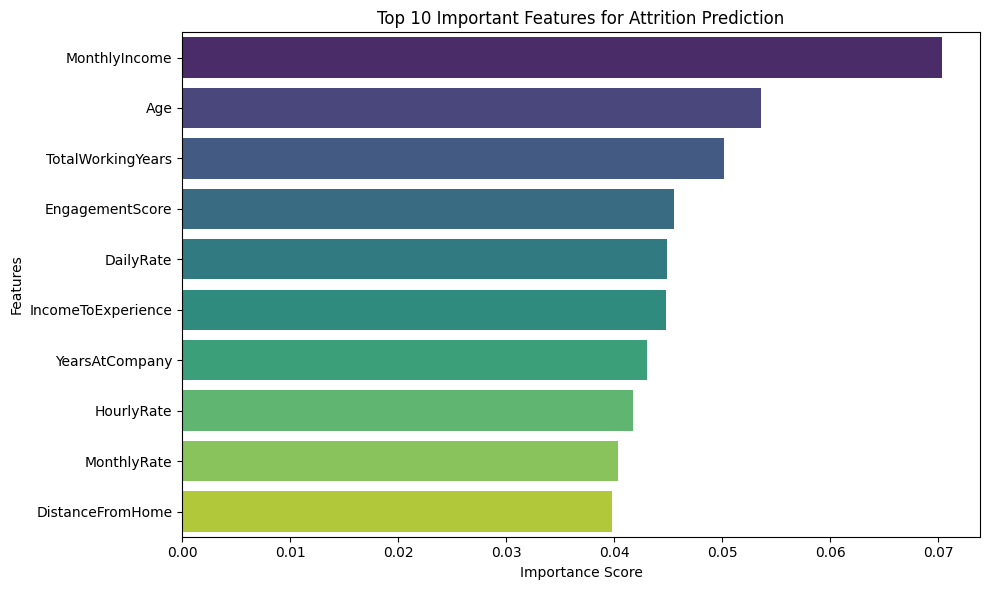

In [12]:
# Feature importance plot
importances = rf_model.feature_importances_
feature_names = X.columns

feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp, hue='Feature', palette='viridis'
            , legend=False)
plt.title('Top 10 Important Features for Attrition Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

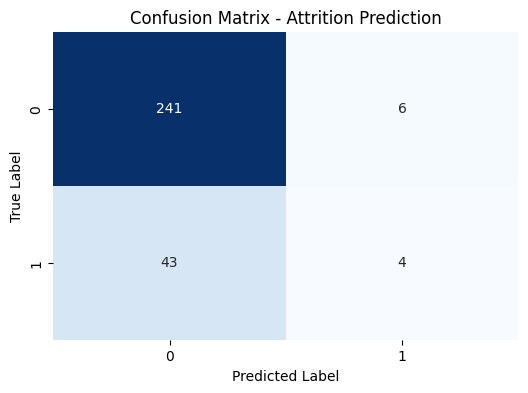

In [13]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Attrition Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [14]:
%%writefile app1.py
import streamlit as st
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Page Configuration
st.set_page_config(
    page_title="Employee Attrition & Risk Scoring System",
    page_icon="🛡️",
    layout="wide"
)

# Load Data and Train Model
@st.cache_resource
def load_data_and_model():
    # File uploader or default path
    df = pd.read_csv('Palo_Alto_Networks.csv')  # Adjust path as needed
    df.drop_duplicates(inplace=True)

    # Keep a copy of original categorical columns for display purposes
    df_original = df.copy()

    # Preprocessing & Encoding for Model Training
    categorical_cols = df.select_dtypes(include=['object', 'string']).columns
    le_dict = {}
    for col in categorical_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        le_dict[col] = le

    # Feature Engineering
    df['IncomeToExperience'] = df['MonthlyIncome'] / (df['TotalWorkingYears'] + 1)
    df['PromotionDelay'] = df['YearsAtCompany'] - df['YearsSinceLastPromotion']
    df['EngagementScore'] = (
        df['EnvironmentSatisfaction'] +
        df['JobSatisfaction'] +
        df['RelationshipSatisfaction'] +
        df['WorkLifeBalance']
    )
    df['WorkloadStress'] = df['OverTime']

    X = df.drop(columns=['Attrition'])
    y = df['Attrition']

    model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    model.fit(X, y)

    return df, df_original, model, X

df, df_original, model, X = load_data_and_model()

# Sidebar Controls
st.sidebar.header("🎛️ HR Dashboard Controls")
risk_threshold = st.sidebar.slider("Select High-Risk Threshold Probability", 0.0, 1.0, 0.60, 0.05)

# App Header
st.title("🛡️ Machine Learning-Based Employee Attrition & Risk Scoring System")
st.markdown("---")

# Compute Predictions for all records
all_probs = model.predict_proba(X)[:, 1]
df_results = df_original.copy()  # Use original dataframe to keep department names readable
df_results['Attrition_Probability'] = all_probs

def get_risk_category(prob):
    if prob < 0.30:
        return 'Low Risk (<30%)'
    elif prob <= 0.60:
        return 'Medium Risk (30–60%)'
    else:
        return 'High Risk (>60%)'

df_results['Risk_Category'] = df_results['Attrition_Probability'].apply(get_risk_category)

# Dashboard Tabs
tab1, tab2, tab3 = st.tabs(["📈 Attrition Risk Overview", "👤 Employee Risk Profile", "🔍 Department-Level View"])

with tab1:
    st.subheader("Overall Attrition Risk Distribution")
    col1, col2, col3 = st.columns(3)

    low_count = len(df_results[df_results['Risk_Category'] == 'Low Risk (<30%)'])
    med_count = len(df_results[df_results['Risk_Category'] == 'Medium Risk (30–60%)'])
    high_count = len(df_results[df_results['Risk_Category'] == 'High Risk (>60%)'])

    col1.metric("Low Risk Employees", low_count)
    col2.metric("Medium Risk Employees", med_count)
    col3.metric("High Risk Employees (>60%)", high_count)

    st.markdown("---")
    st.subheader("Filtered High-Risk Employee List")
    high_risk_df = df_results[df_results['Attrition_Probability'] >= risk_threshold]
    st.dataframe(high_risk_df[['Age', 'Department', 'JobRole', 'MonthlyIncome', 'Attrition_Probability', 'Risk_Category']])

with tab2:
    st.subheader("Individual Employee Risk Profile & Selector")
    emp_index = st.number_input("Enter Employee Index", min_value=0, max_value=len(df)-1, value=0)

    emp_data = df_results.iloc[[emp_index]]
    prob = emp_data['Attrition_Probability'].values[0]
    cat = emp_data['Risk_Category'].values[0]

    col_a, col_b = st.columns(2)
    col_a.metric("Selected Employee Index", emp_index)
    col_b.metric("Attrition Probability", f"{prob:.2%}")

    st.write(f"**Risk Category:** {cat}")
    st.write("### Key Employee Details:")
    st.json(emp_data.to_dict(orient='records')[0])

with tab3:
    st.subheader("Department-Level Risk Analysis")
    dept_risk = df_results.groupby('Department')['Attrition_Probability'].mean().reset_index()
    st.dataframe(dept_risk)
    st.bar_chart(dept_risk.set_index('Department'))

Writing app1.py


In [15]:
import subprocess
subprocess.Popen(["streamlit", "run", "app.py", "--server.port=8501"])
print("Streamlit app is ready!")

Streamlit app is ready!


In [16]:
# Localtunnel install
!npm install -g localtunnel

# Port 8501 link generate
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙
added 22 packages in 4s
⠙
⠙3 packages are looking for funding
⠙  run `npm fund` for details
⠙⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹your url is: https://nasty-flowers-arrive.loca.lt
^C
